In [21]:
import pandas as pd

train = pd.read_csv('train.csv')

print(train.shape)
print(train.info())


(250000, 94)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 94 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          250000 non-null  object 
 1   layout_id                   250000 non-null  object 
 2   scenario_id                 250000 non-null  object 
 3   order_inflow_15m            220436 non-null  float64
 4   unique_sku_15m              220076 non-null  float64
 5   avg_items_per_order         220377 non-null  float64
 6   urgent_order_ratio          220246 non-null  float64
 7   heavy_item_ratio            220384 non-null  float64
 8   cold_chain_ratio            220549 non-null  float64
 9   sku_concentration           220301 non-null  float64
 10  robot_active                250000 non-null  int64  
 11  robot_idle                  250000 non-null  int64  
 12  robot_charging              250000 non-null  int64  
 13  r

In [22]:
print(train['avg_delay_minutes_next_30m'].describe())

count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
25%           4.278801
50%           9.032652
75%          25.791869
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64


In [23]:
X = train.drop(['ID', 'layout_id', 'scenario_id', 'avg_delay_minutes_next_30m'], axis=1)
y = train['avg_delay_minutes_next_30m']

groups = train['layout_id'].copy()


In [24]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor
import numpy as np

gkf = GroupKFold(n_splits=5)

maes = []
for tr_idx, va_idx in gkf.split(X, y, groups=groups):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = LGBMRegressor()
    model.fit(X_tr, np.log1p(y_tr))

    pred = np.expm1(model.predict(X_va))

    mae = mean_absolute_error(y_va, pred)
    maes.append(mae)

print(np.mean(maes))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005959 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19685
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 90
[LightGBM] [Info] Start training from score 2.423999
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19683
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 90
[LightGBM] [Info] Start training from score 2.415848
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

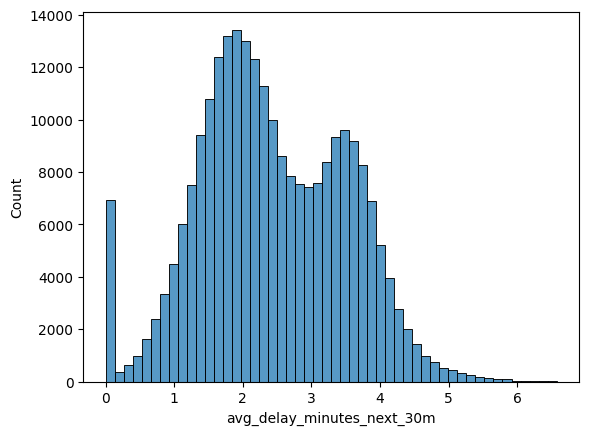

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(np.log1p(train['avg_delay_minutes_next_30m']), bins=50)
plt.show()

In [26]:
from lightgbm import LGBMRegressor
import numpy as np

model = LGBMRegressor()
model.fit(X, np.log1p(y))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19684
[LightGBM] [Info] Number of data points in the train set: 250000, number of used features: 90
[LightGBM] [Info] Start training from score 2.422582


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


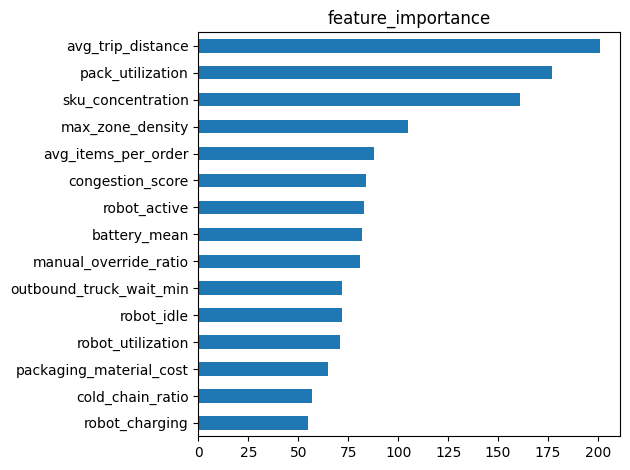

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15).sort_values().plot(kind='barh')
plt.title('feature_importance')
plt.tight_layout()
plt.show()

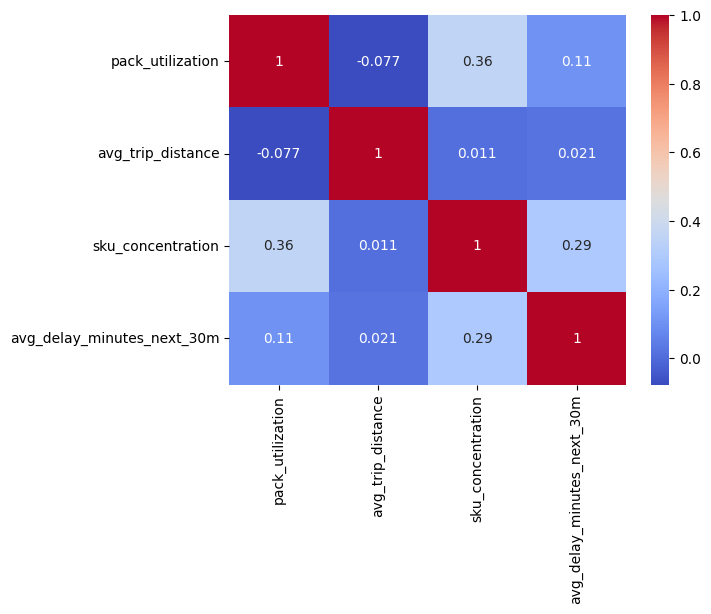

In [29]:
import seaborn as sns
top_features = ['pack_utilization', 'avg_trip_distance', 'sku_concentration',
                'avg_delay_minutes_next_30m']
sns.heatmap(train[top_features].corr(), annot=True, cmap='coolwarm')
plt.show()

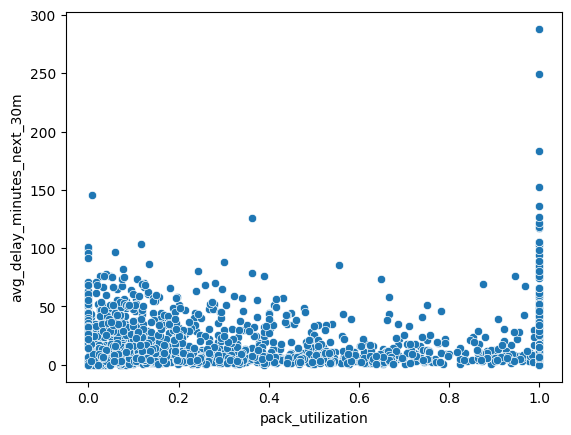

In [30]:
sample = train.sample(2000)
sns.scatterplot(data=sample, x='pack_utilization', y='avg_delay_minutes_next_30m')
plt.show()
